In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()
os.chdir(os.environ.get('DATASET_PATH'))

In [4]:
df = pd.read_csv('concrete_data.csv')
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [6]:
df.isnull().sum().sum()   # no null values 

np.int64(0)

<Axes: xlabel='Cement', ylabel='Density'>

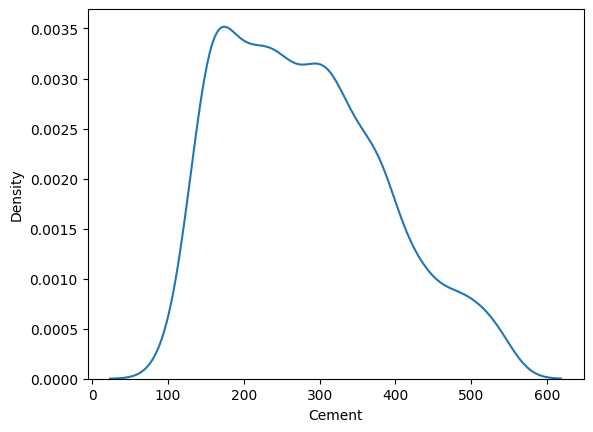

In [58]:
sns.kdeplot(data= df , x='Cement')

In [13]:
# what if we scale the data first 
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
new_df = scalar.fit_transform(df)

new_df = pd.DataFrame(new_df , columns=df.columns)
new_df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,0.863154,-1.217670,-0.279733,2.645408
1,2.477915,-0.856888,-0.847144,-0.916764,-0.620448,1.056164,-1.217670,-0.279733,1.561421
2,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,3.553066,0.266627
3,0.491425,0.795526,-0.847144,2.175461,-1.039143,-0.526517,-2.240917,5.057677,0.313340
4,-0.790459,0.678408,-0.847144,0.488793,-1.039143,0.070527,0.647884,4.978487,0.507979
...,...,...,...,...,...,...,...,...,...
1025,-0.045645,0.488235,0.564545,-0.092171,0.451410,-1.323005,-0.065893,-0.279733,0.506781
1026,0.392819,-0.856888,0.960068,0.676200,0.702626,-1.994680,0.496893,-0.279733,-0.277762
1027,-1.270088,0.759579,0.850635,0.521589,-0.017528,-1.036064,0.080107,-0.279733,-0.725729
1028,-1.168610,1.308065,-0.847144,-0.279579,0.853356,0.214641,0.191166,-0.279733,-0.182539


mean -> -0.00
std -> 1.00


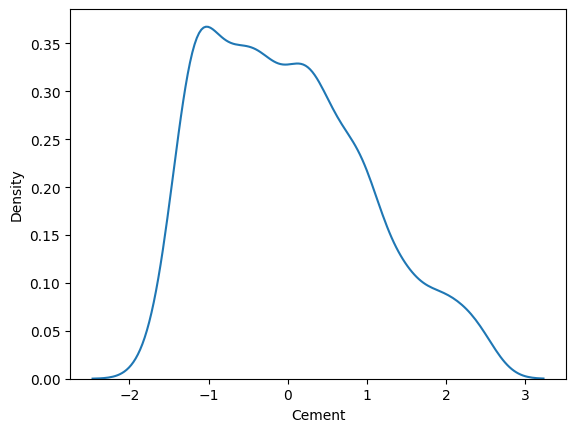

In [57]:
sns.kdeplot(data=new_df, x='Cement')
print(f"mean -> {new_df.Cement.mean():.2f}")
print(f"std -> {new_df.Cement.std():.2f}")

### Yeo - Johnson transformation


In [26]:
from sklearn.preprocessing import PowerTransformer

pow_trans = PowerTransformer()
pow_trans_df = pow_trans.fit_transform(new_df)

pow_trans_df = pd.DataFrame(pow_trans_df, columns=df.columns)
pow_trans_df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,2.056508,-0.952052,-0.879672,-0.916616,-0.566981,0.862194,-1.196147,0.009505,2.277308
1,2.056508,-0.952052,-0.879672,-0.916616,-0.566981,1.057562,-1.196147,0.009505,1.466847
2,0.603951,0.998193,-0.879672,2.155435,-1.154810,-0.530827,-2.077335,2.033094,0.357897
3,0.603951,0.998193,-0.879672,2.155435,-1.154810,-0.530827,-2.077335,2.141250,0.402112
4,-0.778911,0.921720,-0.879672,0.493335,-1.154810,0.064198,0.624899,2.136860,0.581981
...,...,...,...,...,...,...,...,...,...
1025,0.092621,0.786298,0.806677,-0.085948,0.604129,-1.318224,-0.120092,0.009505,0.580894
1026,0.516259,-0.952052,1.068425,0.679235,0.815850,-1.978349,0.462154,0.009505,-0.195276
1027,-1.425337,0.975226,1.000745,0.525897,0.154557,-1.035222,0.026789,0.009505,-0.701995
1028,-1.283690,1.286162,-0.879672,-0.273966,0.935670,0.208671,0.140613,0.009505,-0.093156


<Axes: xlabel='Cement', ylabel='Density'>

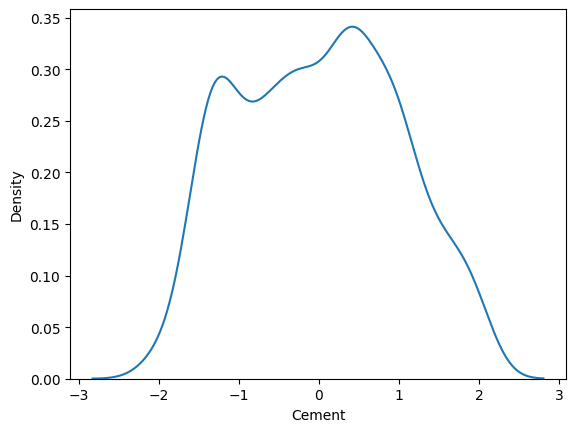

In [60]:
sns.kdeplot(data= pow_trans_df , x='Cement')

In [ ]:
### without doing scaling on data 
pow_trans2 = PowerTransformer(standardize=True)
pow_trans2.fit(df)

,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",True
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True


In [31]:
pow_trans2_df = pow_trans2.transform(df)
pow_trans2_df = pd.DataFrame(pow_trans2_df, columns= df.columns)
pow_trans2_df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,1.994342,-1.057530,-0.902763,-0.914487,-0.327700,0.862160,-1.208485,0.111732,2.241567
1,1.994342,-1.057530,-0.902763,-0.914487,-0.327700,1.057114,-1.208485,0.111732,1.449245
2,0.607415,1.001476,-0.902763,2.136453,-1.225815,-0.530500,-2.085749,2.129725,0.357062
3,0.607415,1.001476,-0.902763,2.136453,-1.225815,-0.530500,-2.085749,2.401692,0.400283
4,-0.744998,0.969970,-0.902763,0.496978,-1.225815,0.065405,0.629012,2.389241,0.576733


<Axes: xlabel='Cement', ylabel='Density'>

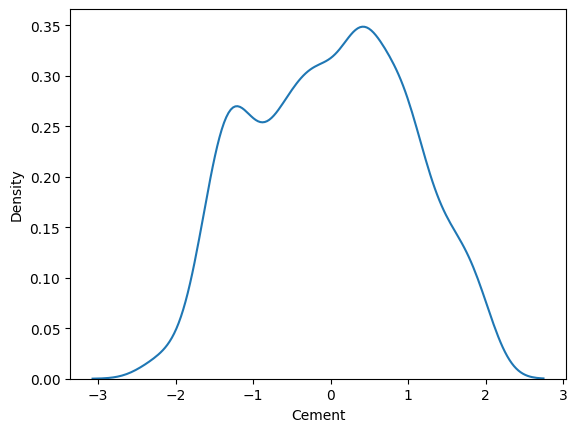

In [32]:
sns.kdeplot(data=pow_trans2_df, x='Cement')

so there is no need of standardizing the data mannually while applying power transformation 

----
---

### Box - Cox Transformation

In [33]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [36]:
df[df['Cement']<0]  # no -ve values so we can use box cox transormation

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength


In [43]:
box_cox = PowerTransformer(method='box-cox',standardize=True)
# box_cox.fit_transform(df['Cement'].reshape(1,1))
temp_df = df['Cement'].to_frame()
box_cox_df = box_cox.fit_transform(temp_df)
box_cox_df = pd.DataFrame(box_cox_df, columns=temp_df.columns)
box_cox_df.head()

,Cement
0,1.994272
1,1.994272
2,0.607399
3,0.607399
4,-0.744848


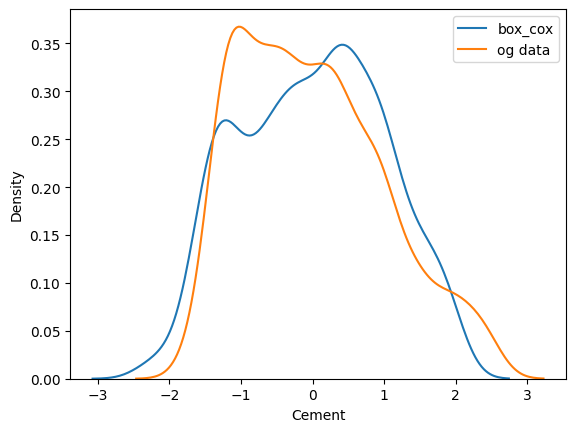

In [55]:
sns.kdeplot(data= box_cox_df , x='Cement', label='box_cox')
sns.kdeplot(data= new_df , x='Cement', label='og data')
plt.legend()